In [7]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

from pyprojroot import here

# Ajout de la racine au sys.path pour rendre les dossiers importables
root_dir = here()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from building_perceptron.data import fetch_and_save_dataset

Note : on peut télécharger le fichier à l'adresse 
https://drive.google.com/file/d/1itXdRo4WJuhqCjtVX4WGvT327WWp4LB7/view?usp=sharing

In [29]:
# Load Data
output_dir = Path(root_dir) / "data" / "raw_data"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "bcw_data.csv"

df = pd.read_csv(output_path, encoding='ascii')

In [30]:
print(f"Doublons dans la colonne 'id': {df['id'].duplicated().sum()}")

Doublons dans la colonne 'id': 0


In [59]:
df = pd.read_csv(output_path, index_col=['id'])
y = df['diagnosis']
X = df.drop(columns=['diagnosis'])

In [61]:
df.head(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


# EDA

In [36]:
import numpy as np
import pandas as pd
# from eda_utils import *

## Encodage, Doublons, colonnes vides

### 1. Encodage
On vérifie l'encodage au tout début d'une EDA pour éviter de charger de la donnée corrompue sans s'en rendre compte.
- Si on essaie de lire un fichier encodé en latin-1 ou cp1252 en lui imposant du utf-8, Python plante immédiatement lors du pd.read_csv().
- Parfois, le fichier s'ouvre sans erreur, mais les caractères sont mal interprétés : Montréal devient MontrÃ©al

In [62]:
import unicodedata
import chardet

with open(output_path, 'rb') as file :
    encodage = chardet.detect(file.read(10000))

print(encodage)

{'encoding': 'ascii', 'confidence': 1.0, 'language': 'eo', 'mime_type': 'text/plain'}


### 

### Analyse des doublons

In [63]:
cols_sans_id = [col for col in df.columns if col != 'id']
nb_doublons = df.duplicated(subset=cols_sans_id).sum()

if nb_doublons == 0:
    print("Aucun doublon trouvé dans le DataFrame.")
else :
    print(f"Nombre de doublons trouvés : {nb_doublons}\nAppelez la fonction duplicate_rows()")

Aucun doublon trouvé dans le DataFrame.


In [ ]:
# Nombre total de lignes en double
# df.duplicated().sum()

# Afficher toutes les lignes impliquées dans un doublon
# df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

# Doublons basés sur une ou plusieurs colonnes
# df[df.duplicated(subset=['id_client'], keep=False)]

# Garder la première occurrence et supprimer les autres
# df_clean = df.drop_duplicates()

# Ou modifier directement le DataFrame existant
# df.drop_duplicates(inplace=True)

### Colonnes vides

In [64]:
# Remplacer les espaces blancs ou chaînes "null" / "None" par np.nan
df_clean = df.replace(r'^\s*$', np.nan, regex=True).replace(['null', 'None', 'nan', 'N/A'], np.nan)

# Tableau récapitulatif des valeurs manquantes
na_summary = pd.DataFrame({
    'Manquants (count)': df_clean.isna().sum(),
    'Manquants (%)': (df_clean.isna().mean() * 100).round(2)
})

na_summary_filtered = na_summary[na_summary['Manquants (count)'] > 0]
if not na_summary_filtered.empty:
    print("Colonnes avec valeurs manquantes :")
    na_summary[na_summary['Manquants (count)'] > 0].sort_values(by='Manquants (%)', ascending=False)
else:
    print("Aucun colonne vide.")


Aucun colonne vide.


In [65]:
# Colonnes dont toutes les valeurs sont NaN"""
empty_columns = df.columns[df.isna().all()].tolist()

empty_columns

[]

In [66]:
# Colonnes contenant des valeurs manquantes explicites : NaN, None, '', 'na', 'null'
missing_vals = {np.nan, None, '', 'na', 'NA', 'null', 'NULL'}
cols = []
for col in df.columns:
    if df[col].isin(missing_vals).any():
        cols.append(col)
cols

[]

### Contrôle et harmonisation des types de données

In [67]:
df.info()
# df.dtypes ou df.info(), puis conversion avec pd.to_datetime(), pd.to_numeric(), ou .astype('category').

<class 'pandas.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-nu

### Analyse de la cardinalité et cohérence du texte

In [41]:
# Identifier le nombre de valeurs uniques 
# df.nunique()

# df['colonne'].value_counts()
# df['colonne'].str.strip().str.lower()

## 2. Statistiques descriptives
Les statistiques descriptives dans une EDA permettent de résumer la forme, le centre et la dispersion de tes données pour repérer immédiatement les anomalies, les asymétries ou les valeurs aberrantes.

In [68]:
df.describe(include='all')

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


1. Mesures de tendance centrale (Où se situe le milieu ?)  
    - Moyenne vs Médiane : La différence entre les deux t'indique la présence d'outliers.  
        Exemple : Si le salaire moyen est de $4\,500\text{ €}$ mais la médiane est à $2\,100\text{ €}$, cela signifie que quelques très hauts salaires tirent la moyenne vers le haut.
    - Mode : La valeur la plus fréquente (très utile pour les variables catégorielles ou discrètes).

2. Mesures de dispersion (Comment les données s'étalent-elles ?)  
    - Écart-type (Standard Deviation) & Variance : Mesurent la distance moyenne des points par rapport à la moyenne.
    - Min et Max : Permettent de vérifier les limites physiques/métier (ex. un âge min de $-5$ ou max de $300$ indique une erreur de saisie).
    - Quartiles ($Q1$, $Q2$/Médiane, $Q3$) & Ecart Interquartile ($IQR = Q3 - Q1$) : L'$IQR$ donne la plage où se trouvent les $50\%$ centraux des données (très robuste aux outliers).

3. Mesures de forme de la distribution  
    - Asymétrie (Skewness) :  
    $>0$ : étalée vers la droite (beaucoup de petites valeurs, quelques très grandes).  
    $<0$ : étalée vers la gauche.
    - Aplatissement (Kurtosis) : Indique si les valeurs sont très concentrées autour de la moyenne ou si les "queues" de distribution sont épaisses (présence fréquente d'outliers).

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, Optional, Any, List, Iterable
import math

def plot_numeric_histograms(
    X: pd.DataFrame,
    bins: int = 40,
    n_cols: int = 3,
    figsize_per_col: Tuple[int, int] = (5, 3),
) -> None:
    """
    Affiche les histogrammes de toutes les colonnes numériques.

    Parameters
    ----------
    X : pd.DataFrame
        Données d'entrée.
    bins : int
        Nombre de bins pour les histogrammes.
    n_cols : int
        Nombre de graphes par ligne.
    figsize_per_col : tuple
        Taille d'un subplot (largeur, hauteur).
    """
    num_cols = X.select_dtypes(include=["number"]).columns
    n_plots = len(num_cols)
    if n_plots == 0:
        return
    n_rows = math.ceil(n_plots / n_cols)
    plt.figure(figsize=(n_cols * figsize_per_col[0], n_rows * figsize_per_col[1]))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(X[col].dropna(), bins=bins)
        plt.xlabel("")   # masque axe X
        plt.ylabel("")   # masque axe Y
        plt.grid(True, alpha=0.3)
        plt.title(col)
    plt.tight_layout()
    plt.show()

In [70]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

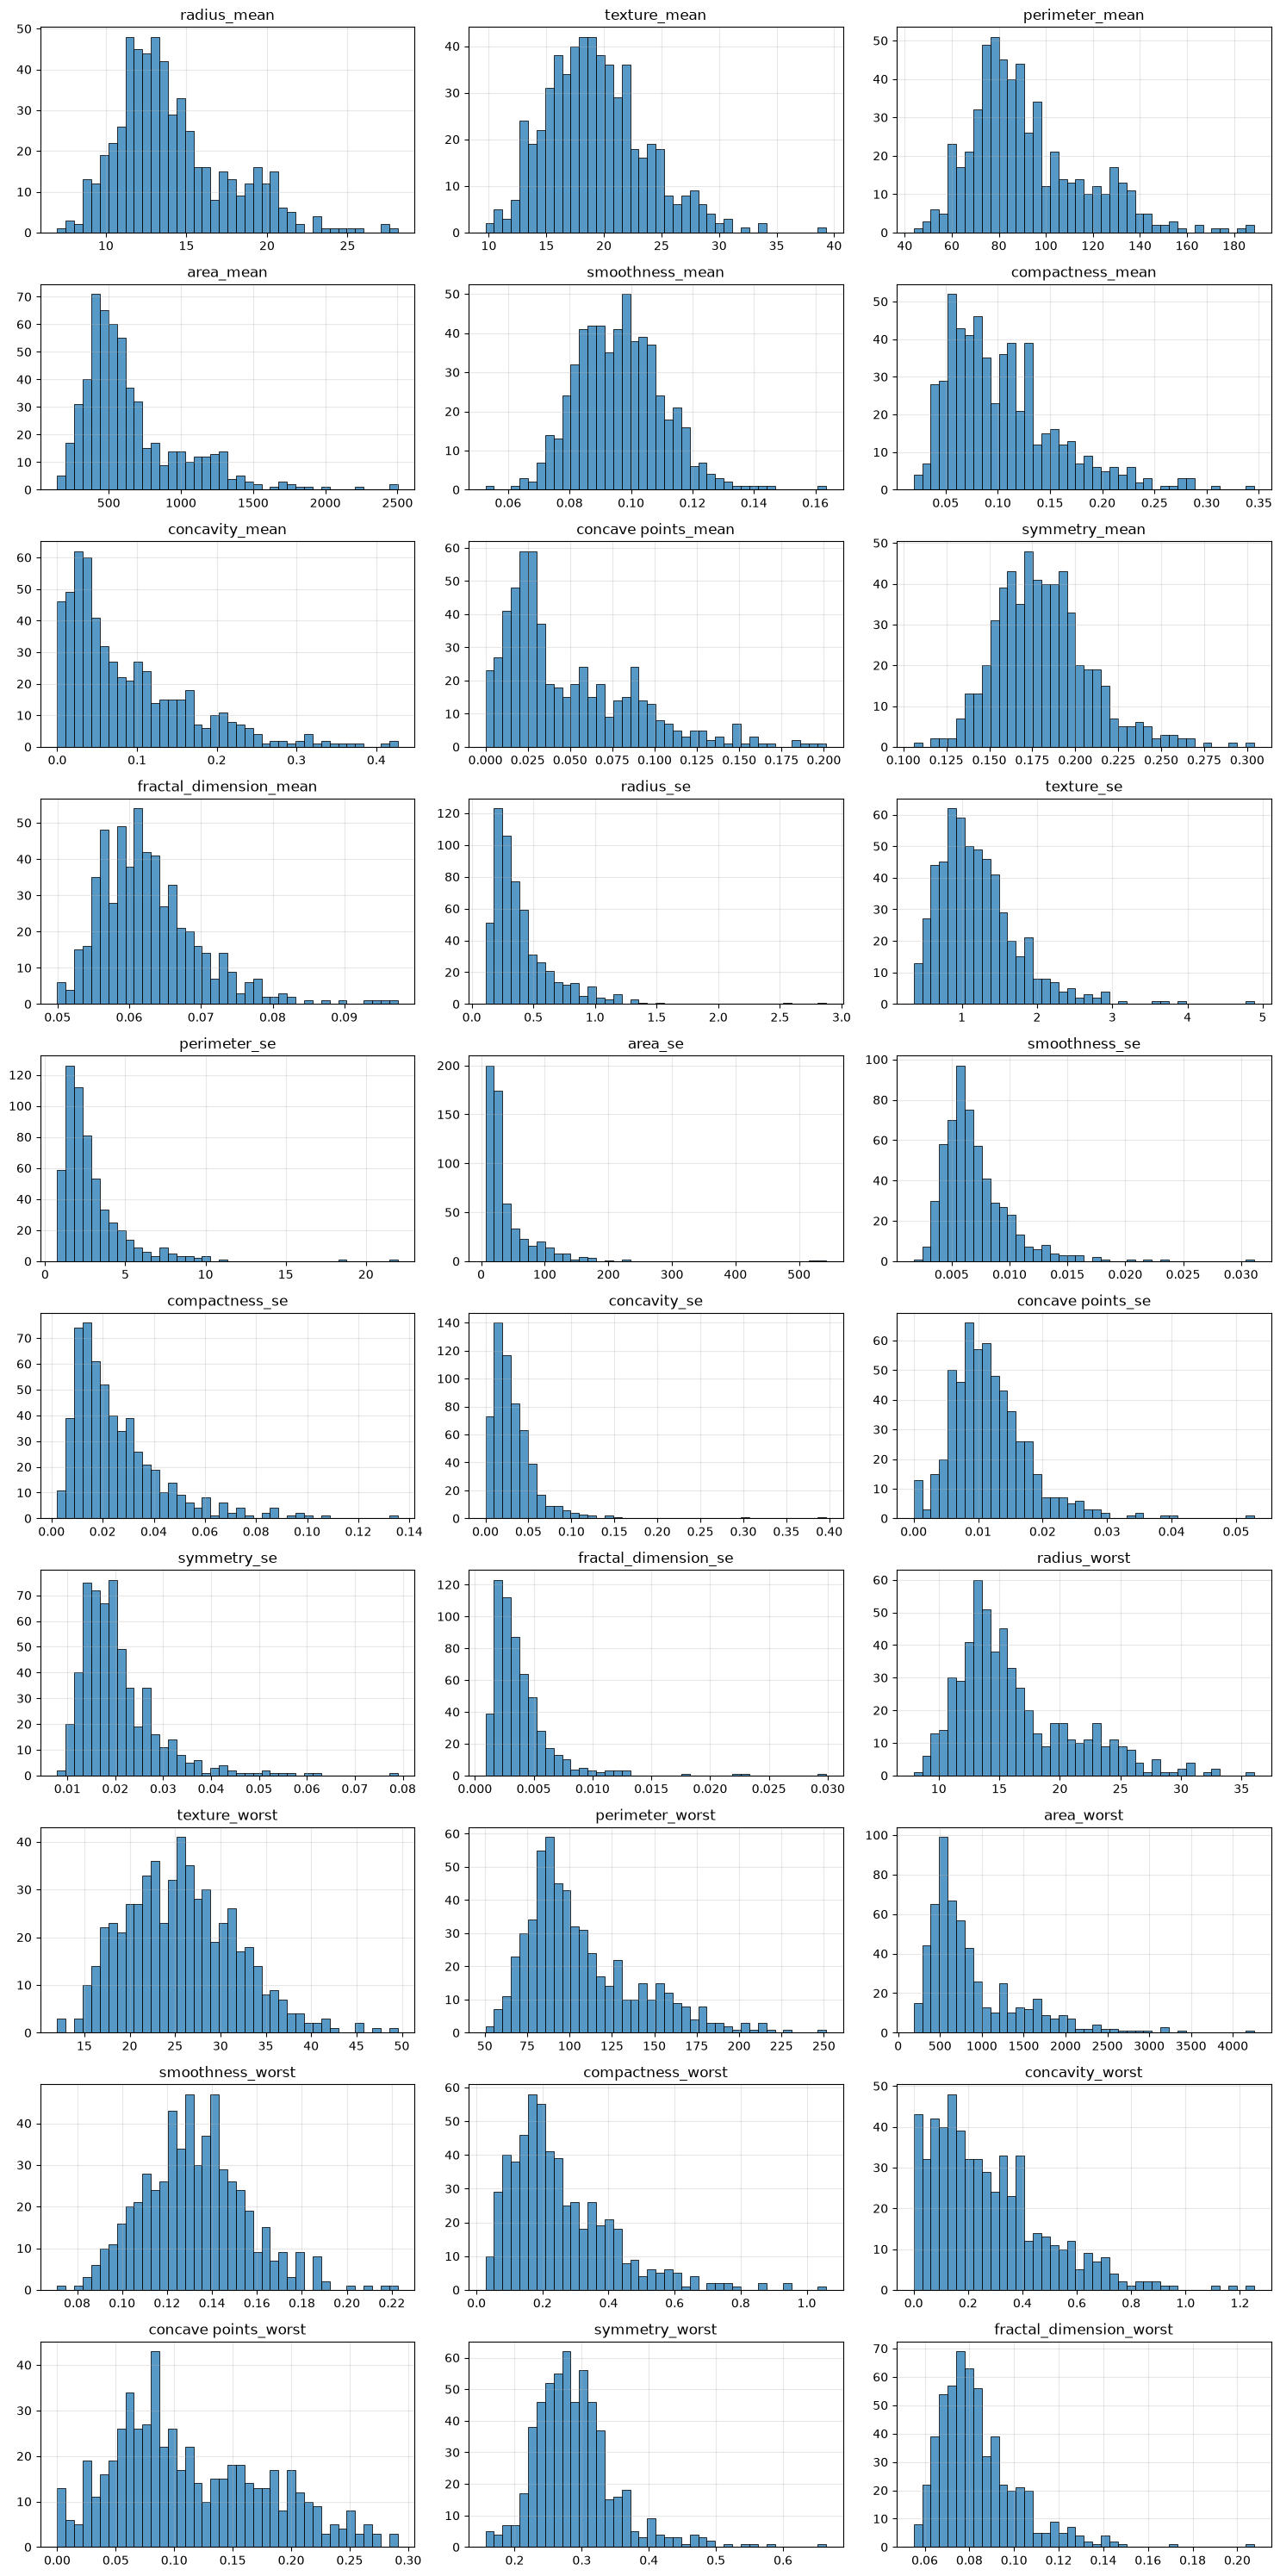

In [71]:
plot_numeric_histograms(df, bins=40, n_cols=3)

### 2a. Standardisation / Normalisation
- La skewness (ou coefficient d'asymétrie) mesure le défaut de symétrie d'une distribution par rapport à sa moyenne.  
    - Skewness $= 0$ : Distribution symétrique (ex. courbe en cloche / gaussienne).
    - Skewness $> 0$ (positive) : Traîne étalée vers la droite (majorité des données à gauche, quelques valeurs très élevées).
    - Skewness $< 0$ (négative) : Traîne étalée vers la gauche (majorité des données à droite, quelques valeurs très faibles).

In [72]:
# Calcul de la skewness pour toutes les colonnes numériques
skewness = df.select_dtypes(include=['number']).skew()

# Filtrer les variables à forte skewness positive (ex: > 0.75 ou > 1.0)
high_skew_cols = skewness[skewness > 0.75].index.tolist()

print(f"Nombre de colonnes fortement asymétriques : {len(high_skew_cols)}")
print("Colonnes concernées :", high_skew_cols)

Nombre de colonnes fortement asymétriques : 24
Colonnes concernées : ['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst']


1. Appliquer une transformation logarithmique  
Comme tes variables ont une forte skewness positive, les quelques grandes valeurs dans la traîne vont exercer une influence disproportionnée sur les poids ($w_i$) du Perceptron pendant la descente de gradient.

$$\text{log1p}(x) = \ln(1 + x)$$


In [74]:
# Application sur tout le DataFrame/array
# X_log = np.log1p(df)

# Ou uniquement sur les colonnes identifiées avec skewness > 0.75
num_df = df.select_dtypes(include=['number'])
cols_to_log = num_df.skew().loc[lambda x: x > 0.75].index

2. Normaliser impérativement (StandardScaler)  
Le Perceptron ne converge pas correctement si tes features n'ont pas la même échelle. Même après le passage en log, tes variables n'auront pas la même variance.

### 2a. Bimodularité
On parle de bimodalité lorsqu'une distribution présente deux pics distincts (deux bosses) au lieu d'un seul. Cela indique la présence de deux sous-populations différentes au sein d'une même variable (ici, les tumeurs bénignes et malignes).

La cause de la bimodalité est identifiée :  
- La première bosse (en orange) correspond aux tumeurs bénignes (B), centrées autour d'un rayon de $11\text{–}13$.
- La seconde bosse (en bleu) correspond aux tumeurs malignes (M), étalées au-delà d'un rayon de $15$.
C'est une excellente variable explicative. Les deux distributions sont clairement décalées : radius_mean possède un pouvoir séparateur très fort.  

Zone de décision : La frontière naturelle se situe vers radius_mean = 15. En dessous de $14$, c'est majoritairement bénin ; au-dessus de $16$, c'est presque exclusivement malin. Chevauchement (zone grise entre 13 et 16) : C'est dans cette zone médiane que les deux courbes se croisent. Un Perceptron simple traçant une hyperplan rigide fera quelques erreurs de classification à cet endroit précis.

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

**radius_mean**, **perimeter_mean**, **area_mean**, **concavity_mean**, **compactness_mean**, **concave points_mean** produisent le même exemple de bimodalité : c'est très cohérent, car toutes ces variables mesurent la taille, la forme ou la géométrie globale de la masse cellulaire.

- Colinéarité physique élevée :
Le rayon (radius), le périmètre (perimeter) et la surface (area) sont géométriquement liés. Quand une tumeur grossit, son rayon, son périmètre et sa surface augmentent simultanément. De même pour les points concaves (concave_points), qui augmentent quand la tumeur devient irrégulière.

- Séparation nette Bénin / Malin :
Dans ce dataset (Breast Cancer Wisconsin), les tumeurs malignes sont globalement plus volumineuses et plus déformées que les tumeurs bénignes. C'est pourquoi chacune de ces variables recrée naturellement les deux bosses : une petite pour la classe Bénigne, une grande pour la classe Maligne.

Le Perceptron fonctionnera très bien en gardant toutes les features. Mais on peut réduire la dimensionnalité (avec une PCA ou en supprimant les colonnes extrêmement corrélées) sans perdre en précision.

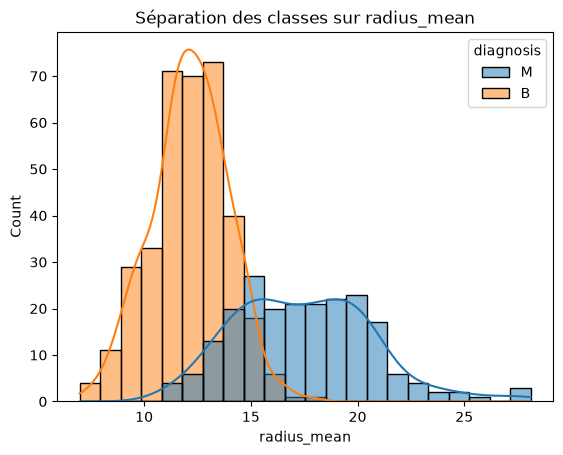

In [83]:
def get_histplot(str):
    sns.histplot(data=df, x=str, hue='diagnosis', kde=True)
    plt.title(f"Séparation des classes sur {str}")
    plt.show()

get_histplot("radius_mean")

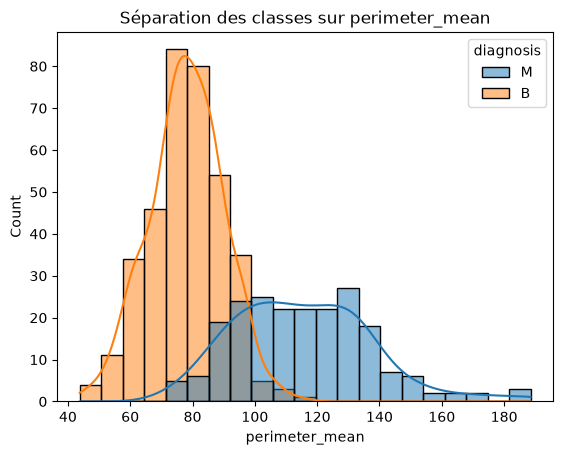

In [86]:
get_histplot("perimeter_mean")

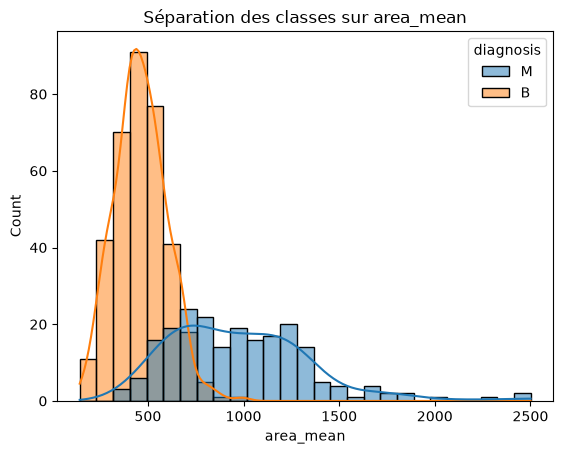

In [88]:
get_histplot("area_mean")

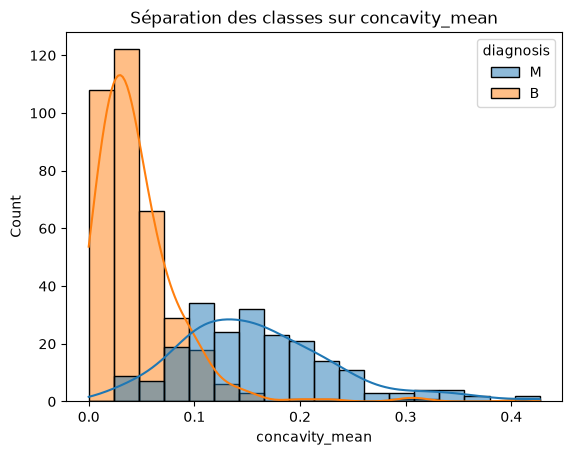

In [104]:
get_histplot("concavity_mean")

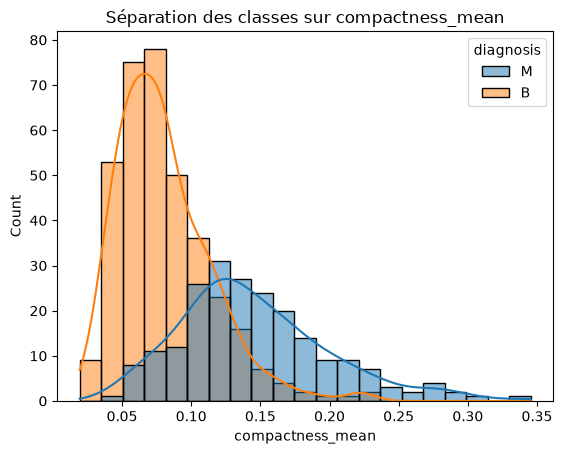

In [99]:
get_histplot("compactness_mean")

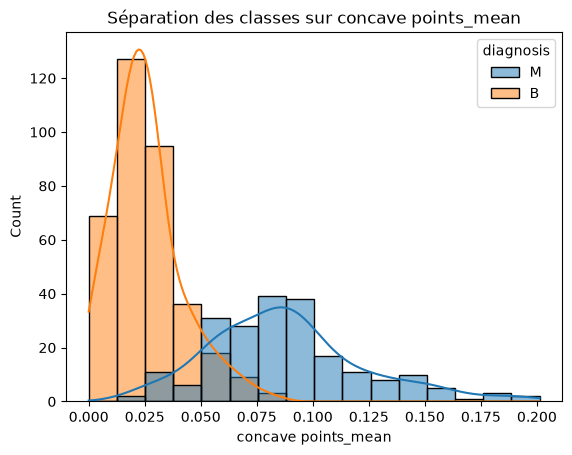

In [103]:
get_histplot("concave points_mean")

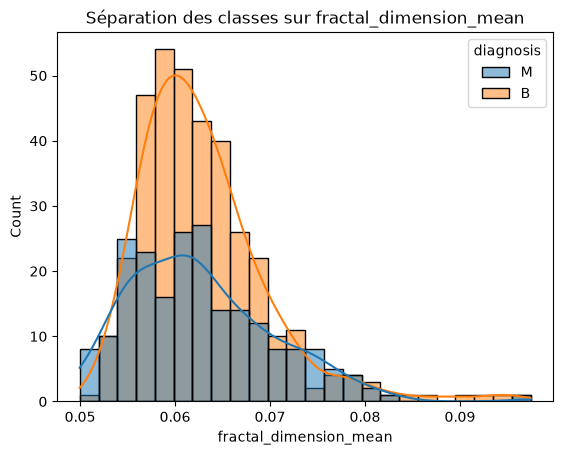

In [105]:
get_histplot("fractal_dimension_mean")

### 2c. Corrélation

1. Encodage de la Target en int

In [121]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

y['diagnosis'] = le.fit_transform(y)

In [116]:
def plot_qualitative(
    X: Union[pd.DataFrame, pd.Series], # Accepte les deux types
    top_n: int = 20,
    n_cols: int = 2,
    figsize_per_col: Tuple[int, int] = (6, 4),
    figsize: Optional[Tuple[int, int]] = None,
    height_per_row: int = 4,
) -> None:
    
    # Conversion si c'est une Series
    if isinstance(X, pd.Series):
        # On donne un nom par défaut si la série n'en a pas
        name = X.name if X.name else "Target"
        X = X.to_frame(name=name)

    """
    Affiche des barplots pour les colonnes qualitatives.

    Parameters
    ----------
    X : pd.DataFrame ou pd.series
        Données d'entrée.
    top_n : int
        Nombre de modalités affichées par colonne.
    n_cols : int
        Nombre de graphes par ligne.
    figsize_per_col : tuple
        Taille d'un subplot (largeur, hauteur).
    """
    cat_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns
    n_plots = len(cat_cols)
    if n_plots == 0:
        return

    n_rows = math.ceil(n_plots / n_cols)
    if figsize is None:
        figsize = (n_cols * figsize_per_col[0], n_rows * height_per_row)

    plt.figure(figsize=figsize)
    

    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        vc = X[col].astype("string").value_counts(dropna=False).head(top_n)
        sns.barplot(x=vc.values, y=vc.index, color="#439cc8")
        plt.xlabel("")
        plt.ylabel("")
        plt.title(col)
        plt.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

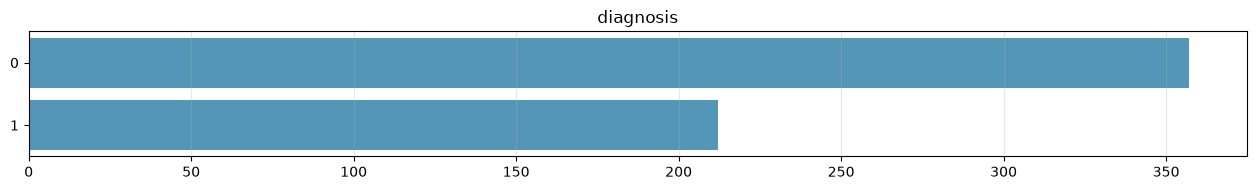

Pourcentage de 1 : 37.26%


In [118]:
plot_qualitative(df["diagnosis"].astype("category"), n_cols=2, figsize=(25, 2))

# Pourcentage de "1" sur l'ensemble des observations
pourcentage_1 = (df["diagnosis"].eq(1).mean()) * 100
print(f"Pourcentage de 1 : {pourcentage_1:.2f}%")

2. Recherche de colinéarité entre features

In [106]:
# Recherche de colinéarité (entre features)
def feature_collinearity(X: pd.DataFrame, threshold: float = 0.8):
    """
    Identifie les paires de features fortement corrélées entre elles (colinéarité).
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame contenant les features numériques.
    threshold : float
        Seuil minimum de corrélation absolue à considérer comme colinéaire.
    
    Returns
    -------
    list
        Liste de tuples (feature1, feature2, correlation) triés par corrélation décroissante.
    """
    # Sélectionner uniquement les colonnes numériques
    X_numeric = X.select_dtypes(include=[np.number])
    
    corr_matrix = X_numeric.corr().abs()
    
    # On ne récupère que la partie supérieure de la matrice pour éviter les doublons (A/B et B/A)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # On filtre par le seuil
    collinear_features = [
        (column, row, upper.loc[row, column]) 
        for column in upper.columns 
        for row in upper.index 
        if upper.loc[row, column] > threshold
    ]
    
    return sorted(collinear_features, key=lambda x: x[2], reverse=True)

In [108]:
collinear_pairs = feature_collinearity( X, threshold=0.9)

print("Paires de variables fortement colinéaires :")
for f1, f2, val in collinear_pairs:
    print(f"{f1} <-> {f2} : {val:.4f}")

Paires de variables fortement colinéaires :
perimeter_mean <-> radius_mean : 0.9979
perimeter_worst <-> radius_worst : 0.9937
area_mean <-> radius_mean : 0.9874
area_mean <-> perimeter_mean : 0.9865
area_worst <-> radius_worst : 0.9840
area_worst <-> perimeter_worst : 0.9776
perimeter_se <-> radius_se : 0.9728
perimeter_worst <-> perimeter_mean : 0.9704
radius_worst <-> radius_mean : 0.9695
radius_worst <-> perimeter_mean : 0.9695
perimeter_worst <-> radius_mean : 0.9651
radius_worst <-> area_mean : 0.9627
area_worst <-> area_mean : 0.9592
perimeter_worst <-> area_mean : 0.9591
area_se <-> radius_se : 0.9518
area_worst <-> perimeter_mean : 0.9415
area_worst <-> radius_mean : 0.9411
area_se <-> perimeter_se : 0.9377
concave points_mean <-> concavity_mean : 0.9214
texture_worst <-> texture_mean : 0.9120
concave points_worst <-> concave points_mean : 0.9102


3. Recherche de corrélations avec la Cible
- En croisant la corrélation avec la cible (diagnosis) et la matrice de colinéarité, on a exactement toutes les informations pour faire un choix stratégique.

In [119]:
from typing import Union

# Recherche de corrélations avec la Cible
def target_correlations(X: pd.DataFrame, y: Union[pd.Series, np.ndarray], n_top: int = 10):
    """
    Calcule la corrélation entre toutes les features numériques et la cible.
    Retourne les n premières features les plus corrélées.
    
    La cible doit être numérique (encodée en amont si elle était catégorique).
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame contenant les features numériques.
    y : Union[pd.Series, np.ndarray]
        Series ou array représentant la cible encodée (numérique : 0/1, etc).
    n_top : int
        Nombre de top features à retourner.
    
    Returns
    -------
    pd.Series
        Corrélations absolues triées en ordre décroissant.
    """
    # Sélectionner uniquement les colonnes numériques de X
    X_numeric = X.select_dtypes(include=[np.number])
    
    # Créer un DataFrame temporaire avec les features numériques et la cible
    temp_df = X_numeric.copy()
    # Accepter à la fois Series et ndarray
    target_values = y.values if isinstance(y, pd.Series) else y
    temp_df['__target__'] = target_values
    
    # Calculer les corrélations avec la cible
    correlations = temp_df.corr()['__target__'].drop(labels=['__target__']).abs().sort_values(ascending=False)
    
    return correlations.head(n_top)

In [126]:
y = df['diagnosis']
X = df.drop(columns=['diagnosis'])

In [129]:
# Top 10 des variables les plus liées au diagnostic
top_corr = target_correlations(X, y, n_top=20)
top_corr

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
area_se                 0.548236
texture_worst           0.456903
smoothness_worst        0.421465
symmetry_worst          0.416294
texture_mean            0.415185
concave points_se       0.408042
Name: __target__, dtype: float64

- Quand deux variables sont très corrélées entre elles ($r > 0{,}90$), on garde celle qui a la plus forte corrélation avec le diagnostic et on supprime l'autre.

In [132]:
import pandas as pd
import numpy as np

def remove_collinear_features(df, target_col, threshold=0.90):
    # 1. Calcul des correlations avec la cible
    target_corr = df.corr()[target_col].abs()
    
    # 2. Matrice de correlation entre features
    features = df.drop(columns=[target_col])
    corr_matrix = features.corr().abs()
    
    # 3. Parcourir le triangle supérieur de la matrice
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    for col1 in upper.columns:
        for col2 in upper.index:
            if upper.loc[col2, col1] > threshold:
                # Si correlation > threshold, on compare leur lien avec la cible
                if target_corr[col1] < target_corr[col2]:
                    to_drop.add(col1)
                else:
                    to_drop.add(col2)
                    
    print(f"Nombre de variables supprimées : {len(to_drop)}")
    print("Variables éliminées :", sorted(list(to_drop)))
    
    return df.drop(columns=list(to_drop))

In [134]:
df_cleaned = remove_collinear_features(df, target_col='diagnosis', threshold=0.90)

Nombre de variables supprimées : 10
Variables éliminées : ['area_mean', 'area_se', 'area_worst', 'concave points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']


### 2d. Overlap

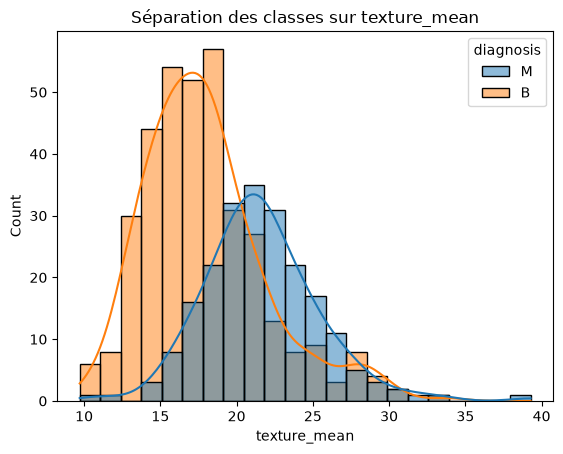

In [96]:
get_histplot("texture_mean")

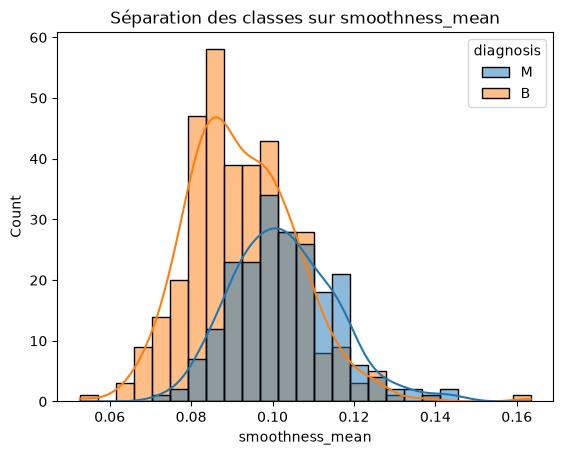

In [95]:
get_histplot("smoothness_mean")

On a un overlap beaucoup plus important : les deux distributions (Bénigne en orange, Maligne en bleu) se croisent largement sur toute la zone entre 15 et 25.

- Un pouvoir séparateur plus faible pris isolément
Contrairement à radius_mean où le creux séparait nettement les deux groupes, texture_mean seule ne permettra pas de trancher facilement : une valeur de 20 peut être aussi bien une tumeur bénigne que maligne.

- Utilisée seule, cette variable générerait beaucoup d'erreurs de classification.

    - Utile en combinaison : Elle apporte quand même une tendance générale (les malignes ont en moyenne une texture plus élevée). Combinée avec radius_mean dans un espace à plusieurs dimensions, elle servira à affiner l'angle de l'hyperplan de séparation.

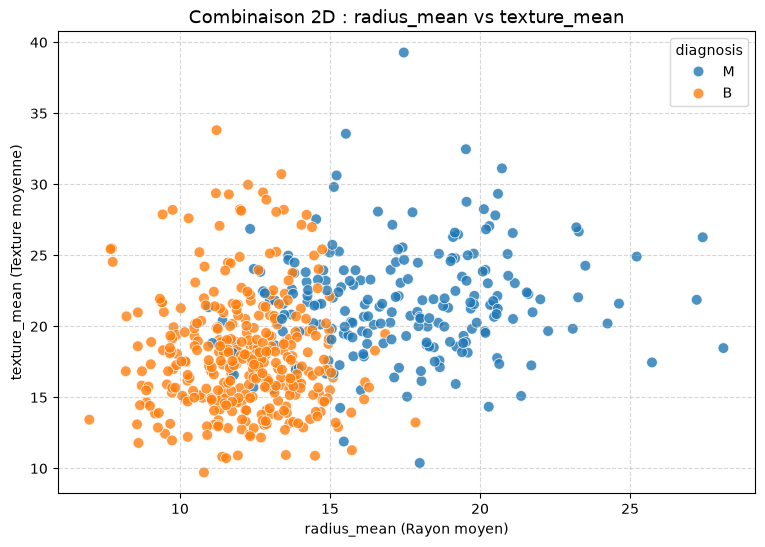

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Nuage de points 2D
sns.scatterplot(
    data=df,
    x='radius_mean',
    y='texture_mean',
    hue='diagnosis',
    palette={'B': 'tab:orange', 'M': 'tab:blue'},
    alpha=0.8,
    s=60
)

plt.title("Combinaison 2D : radius_mean vs texture_mean", fontsize=13)
plt.xlabel("radius_mean (Rayon moyen)")
plt.ylabel("texture_mean (Texture moyenne)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Note : Les deux clusters sont bien formés :
- En bas à gauche (orange) : Les tumeurs bénignes (faible rayon, faible/moyenne texture).
- En haut à droite (bleu) : Les tumeurs malignes (rayon élevé, texture moyenne/forte).

Les variables comme symmetry_mean et fractal_dimension_mean se traduisent par deux gaussiennes fortement chevauchées. Pour symmetry_mean, le léger décalage entre les cloches conserve une petite utilité en $N$ dimensions pour affiner l'hyperplan du Perceptron. En revanche, pour fractal_dimension_mean, les deux gaussiennes sont quasiment confondues (corrélation proche de $0$ avec la cible) : elle n'apporte aucun signal exploitable et peut être supprimée."

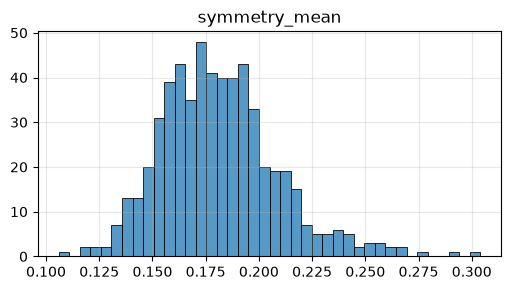

In [ ]:
plot_numeric_histograms(df[["symmetry_mean"]], bins=40, n_cols=2), ["fractal_dimension_mean"]

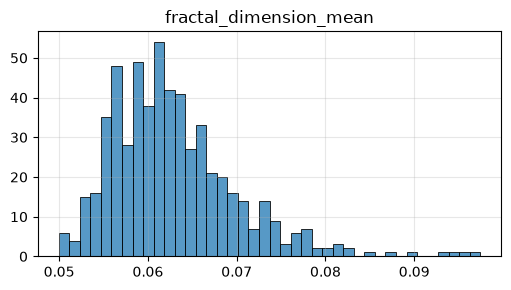

In [141]:
plot_numeric_histograms(df[["fractal_dimension_mean"]], bins=40, n_cols=2)

In [142]:
df_cleaned.drop(columns=['fractal_dimension_mean'], inplace=True)

In [143]:
df_cleaned.columns

Index(['diagnosis', 'smoothness_mean', 'compactness_mean', 'symmetry_mean',
       'radius_se', 'texture_se', 'smoothness_se', 'compactness_se',
       'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'texture_worst', 'perimeter_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

### 3a. Standardisation / Normalisation
- La skewness (ou coefficient d'asymétrie) mesure le défaut de symétrie d'une distribution par rapport à sa moyenne.  
    - Skewness $= 0$ : Distribution symétrique (ex. courbe en cloche / gaussienne).
    - Skewness $> 0$ (positive) : Traîne étalée vers la droite (majorité des données à gauche, quelques valeurs très élevées).
    - Skewness $< 0$ (négative) : Traîne étalée vers la gauche (majorité des données à droite, quelques valeurs très faibles).

In [144]:
# Calcul de la skewness pour toutes les colonnes numériques
skewness = df_cleaned.select_dtypes(include=['number']).skew()

# Filtrer les variables à forte skewness positive (ex: > 0.75 ou > 1.0)
high_skew_cols = skewness[skewness > 0.75].index.tolist()

print(f"Nombre de colonnes fortement asymétriques : {len(high_skew_cols)}")
print("Colonnes concernées :", high_skew_cols)

Nombre de colonnes fortement asymétriques : 14
Colonnes concernées : ['compactness_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'perimeter_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst']


1. Appliquer une transformation logarithmique  
Comme tes variables ont une forte skewness positive, les quelques grandes valeurs dans la traîne vont exercer une influence disproportionnée sur les poids ($w_i$) du Perceptron pendant la descente de gradient.

$$\text{log1p}(x) = \ln(1 + x)$$

In [145]:
# Application sur tout le DataFrame/array
# X_log = np.log1p(df)

# Ou uniquement sur les colonnes identifiées avec skewness > 0.75
num_df = df_cleaned.select_dtypes(include=['number'])
cols_to_log = num_df.skew().loc[lambda x: x > 0.75].index

In [ ]:
cols_to_log

Index(['compactness_mean', 'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'perimeter_worst', 'compactness_worst',
       'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

2. Normaliser impérativement (StandardScaler)  
Le Perceptron ne converge pas correctement si tes features n'ont pas la même échelle. Même après le passage en log, tes variables n'auront pas la même variance.

In [148]:
# 1. Copie du DataFrame de travail
X = df_cleaned.drop(columns=['diagnosis']).copy()

# 2. Identification des colonnes asymétriques (skewness > 0.75)
cols_to_log = X.skew().loc[lambda x: x > 0.75].index

# 3. Application du Log1p uniquement sur ces colonnes
X[cols_to_log] = np.log1p(X[cols_to_log])

# 4. Normalisation StandardScaler (Z-score) sur TOUTES les features
mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X - mean) / std

In [149]:
X_scaled.head(5)

,smoothness_mean,compactness_mean,symmetry_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,perimeter_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,
842302,1.567087,3.147905,2.215566,2.492886,-0.549016,-0.213123,1.330175,0.776444,0.664778,1.156375,0.911137,-1.358098,2.020380,1.306537,2.477207,2.001463,2.294058,2.680256,1.938031
842517,-0.826235,-0.481152,0.001391,0.656321,-0.964764,-0.605938,-0.698945,-0.457665,0.263881,-0.810342,-0.098563,-0.368879,1.501000,-0.375282,-0.411338,-0.077554,1.086129,-0.228539,0.292244
84300903,0.941382,1.075943,0.938859,1.396029,-0.831972,-0.296399,0.830051,0.240238,1.426548,0.242682,0.295998,-0.023953,1.361422,0.526944,1.145225,0.928536,1.953282,1.176818,0.211793
84348301,3.280667,3.253358,2.864862,0.466803,-0.003830,0.692217,2.729515,0.875786,1.118059,4.684454,2.051939,0.133866,-0.130157,3.391291,3.446370,1.906242,2.173873,5.482631,4.809023
84358402,0.280125,0.569122,-0.009552,1.435846,-0.845816,1.485018,-0.040599,0.885085,1.147156,-0.360403,0.502419,-1.465481,1.354633,0.220362,-0.280261,0.699619,0.728618,-0.888201,-0.395010


In [147]:
# Séparer Train et Test (en Pure NumPy) :
# 
# Python
# # Mélange des indices pour éviter tout biais d'ordre
# np.random.seed(42)
# indices = np.random.permutation(len(X_scaled))
# 
# train_size = int(0.8 * len(X_scaled))
# train_idx, test_idx = indices[:train_size], indices[train_size:]
# 
# X_train, X_test = X_scaled.iloc[train_idx].values, X_scaled.iloc[test_idx].values
# y_train, y_test = y[train_idx], y[test_idx]